# EO-LINCS project: Cube generation for Scientific Case Study (SCS) 3

## Model-Data Fusion for Understanding Carbon State-Flux Relationships Across Space

**Objective**: SCS3 aims to improve the accuracy of ecosystem carbon cycle models by integrating in-situ observation networks with complementary EO products as inputs. The data cubes will be generated in a manner that allows seamless integration within the [SINDBAD](https://sindbad-mdi.org/) ecosystem modelling framework.

**Outcomes**: Use a terrestrial carbon model structure that can deliver a process understanding of carbon stateflux relationships across space by leveraging and cross-comparing EO data of biomass and vegetation states 
(fAPAR, LAI, vegetation fraction, etc.) together with ecosystem carbon flux measurements and estimates. 
Additionally, provide open-source novel MDI tools and workflows for community use paving the way for 
adoption by other data-assimilation frameworks.

**Required Datasets**

For this science case, we use small spatial cutouts around flux towers from the following datasets:

- **[Sentinel-2 L2A](https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a)** 
- **[ERA5-Land](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=overview)** 
- **[ESA CCI Biomass](https://climate.esa.int/en/projects/biomass/)**


-------------------------------------------------------------

## Overview of the Cube Generation Pipeline

This notebook demonstrates how users can access the required datasets via the [xcube Multi-Source Data Store](https://xcube-dev.github.io/xcube-multistore/). The full example is available in the [GitHub repository](https://github.com/xcube-dev/xcube-multistore/tree/main/examples/example3). All parameters controlling the cube generation workflow are defined in the configuration file [config.yml](config.yml).

Comprehensive documentation of the configuration schema is available on the [documentation webpage](https://xcube-dev.github.io/xcube-multistore/config/). A step-by-step example showing how to set up a configuration file—while extracting information from multiple data stores—is provided here: [Setup Config YAML File](https://xcube-dev.github.io/xcube-multistore/examples/setup_config/).

In this notebook, we provide:
- A concise preview of the configuration file (summarized in a table)
- The requested geospatial domain
- A walkthrough of the cube generation process

---

### Requirements

Before proceeding, ensure that all required dependencies are installed.

Create the conda environment using the following command:

`conda env create -f environment.yml`

The corresponding file can be found here: [environment.yml](../environment.yml)

After creation, activate the environment:

`conda activate eo-lincs-scs3`

Next, accessing ERA5 reanalysis data via the Copernicus Data Store (CDS) requires a valid CDS API key. This can be obtained by following the instructions in the [xcube-cds documentation](https://github.com/xcube-dev/xcube-cds#obtain-a-cds-personal-access-token).

Once obtained, the credentials must be added to the configuration file. Because the configuration file is generated programmatically while iterating over the flux tower sites, the credentials should be inserted into the Python code shown below, at the end of Cell 5 in the section labeled `# add CDS data store`.

---

### Running the Pipeline

Once all dependencies are installed, the final data cubes can be generated by executing this notebook.

The results will be stored locally in the `data` directory on the top level of the repository, as defined in the [configuration YAML file](config.yml#L95). Note that the user can change the `storage` data store by specifying a different location, or by selecting an alternative backend such as a `"s3"` data store to store the final data cubes in object storage. the Initial visualisations of the generated cubes are displayed at the end of the notebook.

---

## Imports

Let's import everything we need:

In [1]:
import yaml

import pandas as pd
from xcube_multistore.multistore import MultiSourceDataStore

---
## Configuration of the Cube Generation Process

You can explore the available options for the configuration file using the function `get_config_schema()`. Run it and expand the fields to see all the properties that can be set, in combination with the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/).  

For guidance on creating your configuration file, you can also refer to the notebook [setup_config.ipynb](https://xcube-dev.github.io/xcube-multistore/examples/setup_config/) or consult the [Configuration Guide](https://xcube-dev.github.io/xcube-multistore/config/) in the documentation.

In [2]:
MultiSourceDataStore.get_config_schema()

Since this science case focuses on small spatial cutouts and long time series around flux towers, the configuration for the `MultiSourceDataStore` is generated programmatically. This enables efficient iteration over individual flux tower sites.

**Sentinel-2 access**, a time-series mode has been implemented in [xcube-stac](https://github.com/xcube-dev/xcube-stac). It identifies the tiles corresponding to the closest WGS Sentinel-2 grid and performs spatial sub-setting while preserving the native 10 m resolution. Bands at lower resolutions (20 m and 60 m) are resampled to the 10 m grid. This approach preserves the data in its most native form and minimises processing during cube generation.  

This mode is available for both [Planetary Computer](https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a) and [CDSE](https://browser.stac.dataspace.copernicus.eu/collections/sentinel-2-l2a). On Planetary Computer, data is stored as GeoTIFF, allowing efficient chunked access, while on CDSE it is stored as JPEG2000, which requires full tile downloads. As a result, Planetary Computer is roughly 10× faster than CDSE when retrieving small cutouts.
Switching between the two data stores only requires updating the store configuration. Replace the respective data store in the configuration YAML:

```yaml
- identifier: stac-pc
  store_id: stac-pc-ardc
```

with:

```yaml
- identifier: stac-cdse
  store_id: stac-cdse-ardc
  store_params:
    key: <CDSE S3 key>
    secret: <CDSE S3 secret>
```

The required CDSE S3 credentials can be generated by following the [CDSE S3 documentation](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets).


For **ERA5-Land**, only a small area around each site is requested. Due to strict request limits from the [Copernicus Climate Data Store (CDS)](https://cds.climate.copernicus.eu/), requests are performed sequentially for each site. The retrieved cubes are stacked and interpolated to the exact tower location, allowing time series extraction at a single point rather than from a bounding box. A new dataset, [ERA5 hourly time series (`reanalysis-era5-single-levels-timeseries`)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview), provides point-level access, but currently offers only a limited set of variables, making it unsuitable for this science case (it is used in SCS 1).

The **ESA CCI dataset** is accessed using [xcube-cci](https://github.com/esa-cci/xcube-cci). It is loaded lazily and resampled on the fly to match the Sentinel-2 grid. This alignment can be specified in the configuration by setting the `grid_mapping` field to the Sentinel-2 data ID.

We will now create the configuration file for the first two flux tower sites as an example.

In [3]:
sites = pd.read_csv("sites.csv")
sites = sites.iloc[:2]
sites

,Site ID,latitude,longitude,IGBP
0,AU-Dry,-15.2588,132.3706,SAV
1,AU-How,-12.4943,131.1523,WSA


In [4]:
time_range = ["2020-01-01", "2020-06-30"]

In [5]:
config = dict(datasets=[])
for index, site in sites.iterrows():    
    # append config for Sentinel-2
    config_ds = dict(
        identifier=f"{site['Site ID']}/sen2",
        store="stac-store",
        data_id="sentinel-2-l2a",
        open_params=dict(
            time_range=time_range,
            point=[site["longitude"], site["latitude"]],
            bbox_width=4000,
            spatial_res=10,
            asset_names=[
                "B01",
                "B02",
                "B03",
                "B04",
                "B05",
                "B06",
                "B07",
                "B08",
                "B8A",
                "B09",
                "B11",
                "B12",
                "SCL",
            ],
        ),
    )
    config["datasets"].append(config_ds)

    # append config for ERA5
    config_ds = dict(
        identifier=f"{site['Site ID']}/era5_land",
        store="cds",
        data_id="reanalysis-era5-land",
        open_params=dict(
            variable_names=[
                "2m_temperature",
                "total_precipitation", 
                "surface_solar_radiation_downwards", 
                "surface_net_solar_radiation", 
                "2m_dewpoint_temperature",    
            ],
            time_range=time_range,
            point=[site["longitude"], site["latitude"]],
            spatial_res=0.1,
        ),
    )
    config["datasets"].append(config_ds)

    # append config for ESA CCI
    config_ds = dict(
        identifier=f"{site['Site ID']}/esa_cci_biomass",
        store="esa-cci-store",
        grid_mapping=f"{site['Site ID']}/sen2",
        data_id="esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.6-0.100m",
        open_params=dict(
            time_range=time_range,
        ),
    )
    config["datasets"].append(config_ds)

# define stores
config["data_stores"] = []
# add storage data store
config_store = dict(
    identifier="storage",
    store_id="file",
    store_params=dict(root="../data"),
)
config["data_stores"].append(config_store)
# add ESA CCI data store
config_store = dict(
    identifier="esa-cci-store",
    store_id="cciodp",
)
config["data_stores"].append(config_store)
# add STAC data store
config_store = dict(
    identifier="stac-store",
    store_id="stac-pc-ardc",
)
config["data_stores"].append(config_store)
# add CDS data store
config_store = dict(
    identifier="cds",
    store_id="cds",
    store_params=dict(
        endpoint_url="https://cds.climate.copernicus.eu/api",
        cds_api_key="917c02bf-1a72-468c-a3b3-482affbdfb87",
        normalize_names=True,
    ),
)
config["data_stores"].append(config_store)

In [6]:
with open("config.yml", "w") as file:
    yaml.dump(config, file, sort_keys=False)

Now, we can initialize the `MultiSourceDataStore` by passing the path to the `config.yml` which currently is on the same level as this notebook.

In [7]:
msds = MultiSourceDataStore("config.yml")

And we can display the overview of the configuration file for each dataset.

In [8]:
msds.display_config()

User-defined ID,Data Store ID,Data Store Params,Data ID,Open Data Params,Grid-Mapping,Format
AU-Dry/sen2,stac-pc-ardc,-,sentinel-2-l2a,"time_range: ['2020-01-01', '2020-06-30']; point: [132.3706, -15.2588]; bbox_width: 4000; spatial_res: 10; asset_names: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'SCL']",-,Zarr
AU-Dry/era5_land,cds,endpoint_url: https://cds.climate.copernicus.eu/api; cds_api_key: 917c02bf-1a72-468c-a3b3-482affbdfb87; normalize_names: True,reanalysis-era5-land,"variable_names: ['2m_temperature', 'total_precipitation', 'surface_solar_radiation_downwards', 'surface_net_solar_radiation', '2m_dewpoint_temperature']; time_range: ['2020-01-01', '2020-06-30']; point: [132.3706, -15.2588]; spatial_res: 0.1",-,Zarr
AU-Dry/esa_cci_biomass,cciodp,-,esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.6-0.100m,"time_range: ['2020-01-01', '2020-06-30']",Like 'AU-Dry/sen2',Zarr
AU-How/sen2,stac-pc-ardc,-,sentinel-2-l2a,"time_range: ['2020-01-01', '2020-06-30']; point: [131.1523, -12.4943]; bbox_width: 4000; spatial_res: 10; asset_names: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'SCL']",-,Zarr
AU-How/era5_land,cds,endpoint_url: https://cds.climate.copernicus.eu/api; cds_api_key: 917c02bf-1a72-468c-a3b3-482affbdfb87; normalize_names: True,reanalysis-era5-land,"variable_names: ['2m_temperature', 'total_precipitation', 'surface_solar_radiation_downwards', 'surface_net_solar_radiation', '2m_dewpoint_temperature']; time_range: ['2020-01-01', '2020-06-30']; point: [131.1523, -12.4943]; spatial_res: 0.1",-,Zarr
AU-How/esa_cci_biomass,cciodp,-,esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.MERGED.6-0.100m,"time_range: ['2020-01-01', '2020-06-30']",Like 'AU-How/sen2',Zarr


We can display the selected bounding box as shown in the following cell.

In [9]:
msds.display_geolocations()

----
## Cube Generation

Cube generation is triggered with a single command, and each dataset is processed sequentially. The workflow applies the following steps as needed:

- Request the dataset
- Perform dataset-specific preprocessing (e.g. spatio-temporal resampling)
- Writing the final datacube to the `data/<site_id>/` output directory  

### Dataset Notes

- **sen2** Generates an analysis-ready datacube by stacking multiple Sentinel-2 Level-2A observations along the time dimension and subsetting to the small cutout. The data is kept in the native UTM grid to minimize reprojection errors.

- **era5land** Provides time series at the flux tower location for the selected variables.

- **esa_cci_biomass** Accessed lazily via the xcube ESA CCI datastore, with on-the-fly resampling aligned to the Sentinel-2 grid.

> **Note:** Most of the logging is related to the Copernicus Data Store (CDS) when retrieving ERA-5 reanalysis data.  

In [10]:
msds.generate()

Dataset identifier,Status,Message,Exception
AU-Dry/sen2,COMPLETED,Dataset 'AU-Dry/sen2' already generated.,-
AU-Dry/era5_land,COMPLETED,Dataset 'AU-Dry/era5_land' finished: 0:06:18,-
AU-Dry/esa_cci_biomass,COMPLETED,Dataset 'AU-Dry/esa_cci_biomass' already generated.,-
AU-How/sen2,COMPLETED,Dataset 'AU-How/sen2' already generated.,-
AU-How/era5_land,COMPLETED,Dataset 'AU-How/era5_land' already generated.,-
AU-How/esa_cci_biomass,COMPLETED,Dataset 'AU-How/esa_cci_biomass' already generated.,-


xcube-cds version 1.4.1
xcube-cds version 1.4.1
xcube-cds version 1.4.1
xcube-cds version 1.4.1
2026-06-18 10:29:56,908 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-06-18 10:29:56,909 INFO Request ID is 98bf1a55-b296-4747-b3a8-d16ac98c5990
2026-06-18 10:29:56,976 INFO status has been updated to accepted
2026-06-18 10:30:18,268 INFO status has been updated to running
2026-06-18 10:30:29,735 INFO status has been updated to successful


1dd62c70048c25016e387511c40e3013.zip:   0%|          | 0.00/193k [00:00<?, ?B/s]

xcube-cds version 1.4.1
xcube-cds version 1.4.1
2026-06-18 10:30:32,620 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-06-18 10:30:32,621 INFO Request ID is e79e6118-df4d-418e-8b03-43d4e07321b4
2026-06-18 10:30:32,675 INFO status has been updated to accepted
2026-06-18 10:30:55,008 INFO status has been updated to running
2026-06-18 10:31:06,493 INFO status has been updated to successful


f9dacb5d8832cbe41cbc6cbe1ae7ab5.zip:   0%|          | 0.00/188k [00:00<?, ?B/s]

...

4b91e03c145c67200477839ca05bd28c.zip:   0%|          | 0.00/112k [00:00<?, ?B/s]

xcube-cds version 1.4.1
2026-06-18 10:35:13,870 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-06-18 10:35:13,871 INFO Request ID is fdd5c7f2-3b25-474e-9994-6646a57a1e1d
2026-06-18 10:35:13,921 INFO status has been updated to accepted
2026-06-18 10:35:35,159 INFO status has been updated to successful


90e17cb577719ff5e5fff787aaad98b0.zip:   0%|          | 0.00/161k [00:00<?, ?B/s]

xcube-cds version 1.4.1
2026-06-18 10:35:36,128 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-06-18 10:35:36,129 INFO Request ID is f2a46609-33a6-4e0f-ad72-f4965ff1795f
2026-06-18 10:35:36,195 INFO status has been updated to accepted
2026-06-18 10:36:00,681 INFO status has been updated to running
2026-06-18 10:36:12,145 INFO status has been updated to successful


3dd6fec4ab454f2a44ef847d140c4f66.zip:   0%|          | 0.00/164k [00:00<?, ?B/s]

----

## Initial Inspection of the Generated Datasets

After cube generation has completed, the datasets can be opened using the xcube datastore framework API as usual.

Note that the multi-source datastore expects a datastore named `storage`. This datastore is defined in the `data_stores` section of the `config.yml` configuration file.


In [11]:
ds = msds.stores.storage.open_data("AU-Dry/sen2.zarr")
ds

<xarray.Dataset> Size: 332MB
Dimensions:      (time: 37, y: 400, x: 400)
Coordinates:
  * time         (time) datetime64[ns] 296B 2020-01-02T01:27:09.024000 ... 20...
  * y            (y) float64 3kB 8.312e+06 8.312e+06 ... 8.308e+06 8.308e+06
  * x            (x) float64 3kB 8.601e+05 8.601e+05 ... 8.641e+05 8.641e+05
    spatial_ref  int64 8B ...
Data variables: (12/13)
    B01          (time, y, x) float32 24MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B02          (time, y, x) float32 24MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B03          (time, y, x) float32 24MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B04          (time, y, x) float32 24MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B05          (time, y, x) float32 24MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B06          (time, y, x) float32 24MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    ...           ...
    B08          (time, y, x) float32 24MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B09          (time, y, x) float32 24MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B11          (time, y, x) float32 24MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B12          (time, y, x) float32 24MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    B8A          (time, y, x) float32 24MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    SCL          (time, y, x) float64 47MB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
Attributes:
    stac_catalog_url:    https://planetarycomputer.microsoft.com/api/stac/v1
    stac_item_id:        S2B_MSIL2A_20200102T012709_R131_T52LHJ_20201002T215923
    stac_item_ids:       {'2020-01-02T01:27:09.024000': ['S2B_MSIL2A_20200102...
    xcube_stac_version:  1.3.1

We can now select a variable for one timestep and plot it for a quick preview of the data.

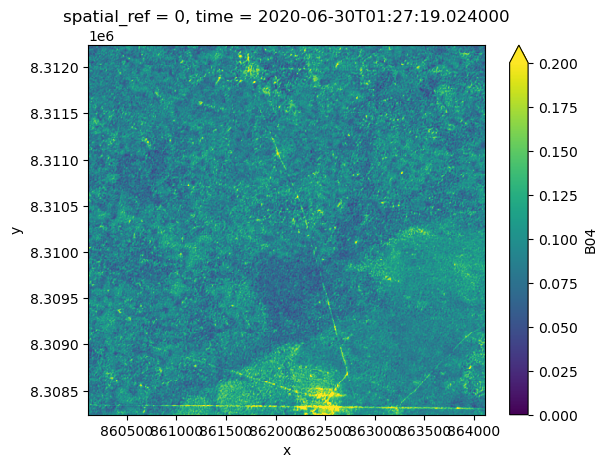

In [12]:
ds.B04.isel(time=-1).plot(vmin=0., vmax=0.2)

The same quicklook can be created for any generated dataset.

In [13]:
ds = msds.stores.storage.open_data("AU-Dry/era5_land.zarr")
ds

<xarray.Dataset> Size: 192kB
Dimensions:  (time: 4368)
Coordinates:
  * time     (time) datetime64[ns] 35kB 2020-01-01 ... 2020-06-30T23:00:00
    expver   (time) <U4 70kB dask.array<chunksize=(552,), meta=np.ndarray>
    lat      float64 8B ...
    lon      float64 8B ...
    number   int64 8B ...
Data variables:
    d2m      (time) float32 17kB dask.array<chunksize=(552,), meta=np.ndarray>
    ssr      (time) float32 17kB dask.array<chunksize=(552,), meta=np.ndarray>
    ssrd     (time) float32 17kB dask.array<chunksize=(552,), meta=np.ndarray>
    t2m      (time) float32 17kB dask.array<chunksize=(552,), meta=np.ndarray>
    tp       (time) float32 17kB dask.array<chunksize=(552,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2026-06-12T10:07 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

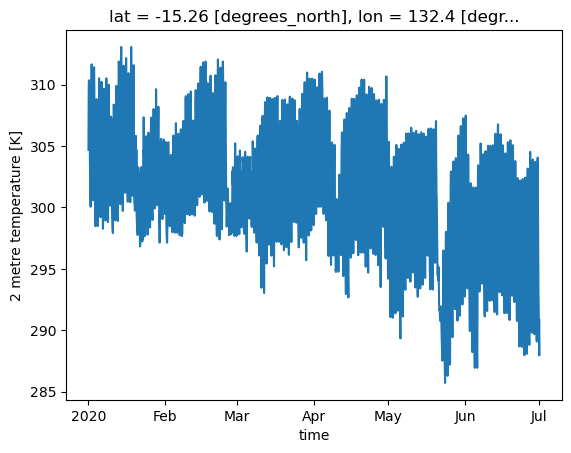

In [14]:
ds.t2m.plot()

In [15]:
ds = msds.stores.storage.open_data("AU-Dry/esa_cci_biomass.zarr")
ds

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 1, y: 400, x: 400)
Coordinates:
  * time         (time) datetime64[ns] 8B 2020-07-01T23:59:59
  * y            (y) float64 3kB 8.312e+06 8.312e+06 ... 8.308e+06 8.308e+06
  * x            (x) float64 3kB 8.601e+05 8.601e+05 ... 8.641e+05 8.641e+05
    spatial_ref  int64 8B ...
Data variables:
    agb          (time, y, x) float32 640kB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
    agb_sd       (time, y, x) float32 640kB dask.array<chunksize=(1, 400, 400), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    date_created:            2026-06-16T13:39:26.361311
    history:                 [{'cube_params': {'time_range': ['2020-01-01T00:...
    processing_level:        L4
    time_coverage_duration:  P365DT23H59M59S
    time_coverage_end:       2020-12-31T23:59:59
    time_coverage_start:     2020-01-01T00:00:00
    title:                   esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-plat...

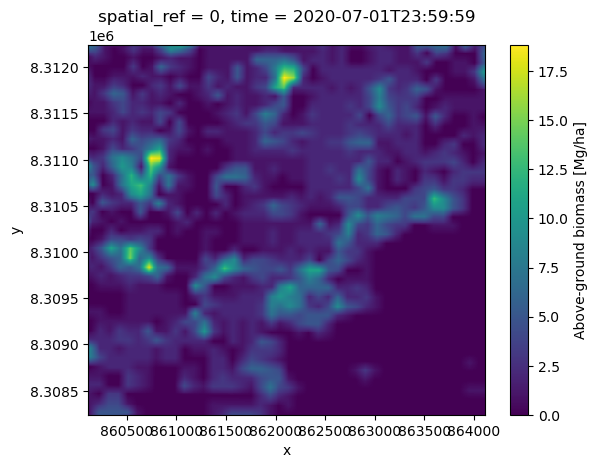

In [16]:
ds["agb"].plot()